#   **House Pricing EDA Project**
*by Vugar Nasirli*

Bu proyekt məlumatların analitikası perspektivindən yanaşmaqla satış üçün nəzərdə tutulmuş evlər haqqında verilmiş məlumat dəstini əvvəlcə məlumat mühəndisliyi bacarıqları ilə məlumatların analitika prosesi üçün ön hazırlığını görəcək, daha sonra hazırlanmış məlumatlara əsasən qərar vermək üçün mühüm olan statistik yanaşmaları tətbiq edərək ümumi qərar verməyə əhəmiyyətli dərəcə yön verəcək nəticcələr çıxaracaq. Son olaraq isə çıxarılmıış nəticələrin düzgün seçilmiş vizuallar əsasında təqdim edilməsiylə sonlanacaq.

Bu proyektdə əsas fokus nöqtəmiz **Python** proqramlaşdırma dilini Data Analitikin arsenalındakı ən güclü silahlardan biri olaraq tətbiq etmək və mühəndislik, riyazi və statistik analiz həmçinin vizuallarla düzgün storytelling bacarıqlarının tandemini göstərmək olacaq.

Alətlər Çantası:
* NumPy
* Pandas
* Matplotlib
* Seaborn

## Data Cleaning and Preprocessing
Bu mərhələdə görəcəyimiz işlər:
* Artıq əldə olunmuş məlumatları oxuyub və saxlamaq. 
* Data tiplərinin düzgün formada dəyişdirilməsi.
* Dataların hesablama zamanı maneə yaradacq artıq məlumatlardan təmizlənməsi.
* Mövcud datanın parçalanaraq yeni datanın əldə olunması yəni daxili datadan yəni data əldə olunması.
* Çatışmayan və yanlış dəyərlərin bərpası və əvəzlənməsi.

### 1. Modulların daxil edilməsi

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets

### 2. Məlumatların oxunması və saxlanması
`Pandas` kitabxanası vasitəsiylə məlumatların mənbədən oxunması və saxlanması.

In [2]:
df = pd.read_csv("house_listings.csv")
df.head()

,category,price,currency,price_1m2,title,address,floor,area,title_deed,repair,mortgage,url,room_number
0,Köhnə tikili,137 000,AZN,2 630 AZN/m²,"Satılır 3 otaqlı köhnə tikili 52 m², 8-ci kilo...",Elşən Süleymanov küç 137,7 / 9,52 m²,var,var,NaN,https://bina.az/items/3858477,3.0
1,Yeni tikili,183 000,AZN,1 790 AZN/m²,"Satılır 2 otaqlı yeni tikili 102 m², Neftçilər m.",Mehdi Abbasov küçəsi,2 / 17,102 m²,yoxdur,var,NaN,https://bina.az/items/3858493,2.0
2,Köhnə tikili,145 000,AZN,2 230 AZN/m²,"Satılır 2 otaqlı köhnə tikili 65 m², Nərimanov r.",Atatürk Prospekti,6 / 9,65 m²,var,var,var,https://bina.az/items/3858489,2.0
3,Köhnə tikili,190 000,AZN,2 000 AZN/m²,"Satılır 3 otaqlı köhnə tikili 95 m², Gənclik m.",Atatürk pr.,4 / 9,95 m²,var,var,var,https://bina.az/items/3858491,3.0
4,Yeni tikili,294 000,AZN,1 550 AZN/m²,"Satılır 3 otaqlı yeni tikili 190 m², Nəsimi r.",Möhsün Sənani küçəsi,6 / 16,190 m²,var,yoxdur,NaN,https://bina.az/items/3858488,3.0


In [3]:
df.shape

(35503, 13)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35503 entries, 0 to 35502
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   category     35466 non-null  str    
 1   price        35466 non-null  str    
 2   currency     35466 non-null  str    
 3   price_1m2    35466 non-null  str    
 4   title        35466 non-null  str    
 5   address      35466 non-null  str    
 6   floor        35466 non-null  str    
 7   area         35466 non-null  str    
 8   title_deed   35466 non-null  str    
 9   repair       33774 non-null  str    
 10  mortgage     11642 non-null  str    
 11  url          35503 non-null  str    
 12  room_number  35466 non-null  float64
dtypes: float64(1), str(12)
memory usage: 3.5 MB


In [5]:
df.isna().sum()

category          37
price             37
currency          37
price_1m2         37
title             37
address           37
floor             37
area              37
title_deed        37
repair          1729
mortgage       23861
url                0
room_number       37
dtype: int64

* Burada ilkin izlənim olaraq deyə bilərik ki bir çox numeric dəyər daşımalı olan columnlarımız string olaraq data tipini sahibdir. Bu isə qəbuledilməzdir və data tipləri düzgün formaya salınmalıdır.
* Əksəriyyət sütunlarımızda eyni sayda NULL dəyər var. Bu isə həmən sətirlərin bütövlükdə NULL olması və analitik olaraq bir dəyər daşımır. 
* Daha sonra url -də NULL dəyərin olmaması unique olma ehtimalını artırır.
* Repair və Mortgage sütunları ciddi məlumat boşluğu var.

### 3. Tip Konvertasiyası
* **price** və **price_1m2** sütunlarındakı mətnsal simvolları (`boşluq`, `'AZN'`, `'AZN/m²'`) təmizləyin.
* Məlumat tipini ədədi (`float`/`integer`) formata çevirin.

In [6]:
# "price" sütunu analiz edirik ki nələri təmizləməliyik.
print(df["price"].str.replace(pat=" ", repl="").str.isalpha().sum())        # Bu bizə göstərir ki boşluqdan başqa string qalıb ya yox 
print(df["price"].str.replace(pat=" ", repl="").str.isnumeric().sum())      # Bu bizə göstərir ki qalan bütün sütunlar numericdi ya yox
print(df["price"].str.replace(pat=" ", repl="").isnull().sum())             # Bu bizə göstərir ki necə sütün null-dır

# NOTE: 
# Nəticədə müəyyən etdik ki "price" sütunumuzda yeganə təmizlənməli olan " " boşluq stringidir.
# Qalan bütün sütunlar ya numericdir ya da null.

0
35466
37


In [7]:
# Təmizlik işlərini yerinə yetiririk.
df["price"] = df["price"].str.replace(pat=" ", repl="").astype("Float64")
df["price"]

# NOTE:
# "price" sütununu təmizləmək və məlumat tipinin dəyişmək üçün əvvəlcə boşluğ stringini ləğv elədik.
# Daha sonra isə məlumat tipini dəyişərək "string"-dən "float"-a çevirdik.

0        137000.0
1        183000.0
2        145000.0
3        190000.0
4        294000.0
           ...   
35498    135000.0
35499    245000.0
35500    309000.0
35501    292000.0
35502    130000.0
Name: price, Length: 35503, dtype: Float64

In [8]:
# price_1m2 sütununu analiz edirik nələri təmizləməliyik
print(df["price_1m2"].str.replace(pat={" ":"", "AZN/m²":""}).str.isalpha().sum())       # Bu bizə hərflərin olduğu bir dəyər qalıb ya yox onu verir
print(df["price_1m2"].str.replace(pat={" ":"", "AZN/m²":""}).str.isnumeric().sum())     # Bu bizə ədədi olaraq neçə sıra qalıb onu verir 
print(df["price_1m2"].str.replace(pat={" ":"", "AZN/m²":""}).isnull().sum())            # Bu bizə null olaraq neçə sütün var onu verir

# NOTE: 
# Nəticədə müəyyən etdik ki "price_1m2" sütunumuzda yeganə təmizlənməli olan " "və "AZN/m²" boşluq stringidir.
# Qalan bütün sütunlar ya numericdir ya da null.

0
35466
37


In [9]:
# Təmizlik işlərini yerinə yetiririk.
df["price_1m2"] = df["price_1m2"].str.replace(pat={" ":"", "AZN/m²":""}).astype("Float64")
df["price_1m2"]

# NOTE:
# "price_1m2" sütununu təmizləmək və məlumat tipinin dəyişmək üçün əvvəlcə boşluğ stringini  və xüsusi ölçü vahidini ləğv elədik.
# Daha sonra isə məlumat tipini dəyişərək "string"-dən "float"-a çevirdik.

0        2630.0
1        1790.0
2        2230.0
3        2000.0
4        1550.0
          ...  
35498    2080.0
35499    2720.0
35500    2310.0
35501    2150.0
35502    2170.0
Name: price_1m2, Length: 35503, dtype: Float64

### 4. Ölçü Vahidinin Silinməsi
* **area** sütunundan `'m²'` simvolunu silin.
* Sütunun məlumat tipini kəsr ədəd (`float`) formatına gətirin.

In [10]:
df["area"] = df["area"].str.replace(pat={" m²":""}).astype("Float64")
df["area"]

0         52.0
1        102.0
2         65.0
3         95.0
4        190.0
         ...  
35498     65.0
35499     90.0
35500    134.0
35501    136.0
35502     60.0
Name: area, Length: 35503, dtype: Float64

In [11]:
print(df["area"].notna().sum())
print(df["area"].isna().sum())

35466
37


### 5. Mətnin Parçalanması
* **floor** sütununu `/` simvoluna əsasən parçalayın.
* İki yeni ədədi sütun yaradın:
    * **current_floor** (mənzilin yerləşdiyi mərtəbə)
    * **total_floors** (binanın ümumi mərtəbə sayı)

In [12]:
df[["current_floor", "total_floors"]] = df["floor"].str.split(pat=" / ", expand=True) # Əvvəlcə split edirik və expand edirik ki dataframe olaraq
df = df.astype(dtype={"current_floor":"Int64", "total_floors":"Int64"})  # Dah sonra data tiplərini düzgün olaraq mənimsədirik
df.head()

,category,price,currency,price_1m2,title,address,floor,area,title_deed,repair,mortgage,url,room_number,current_floor,total_floors
0,Köhnə tikili,137000.0,AZN,2630.0,"Satılır 3 otaqlı köhnə tikili 52 m², 8-ci kilo...",Elşən Süleymanov küç 137,7 / 9,52.0,var,var,NaN,https://bina.az/items/3858477,3.0,7,9
1,Yeni tikili,183000.0,AZN,1790.0,"Satılır 2 otaqlı yeni tikili 102 m², Neftçilər m.",Mehdi Abbasov küçəsi,2 / 17,102.0,yoxdur,var,NaN,https://bina.az/items/3858493,2.0,2,17
2,Köhnə tikili,145000.0,AZN,2230.0,"Satılır 2 otaqlı köhnə tikili 65 m², Nərimanov r.",Atatürk Prospekti,6 / 9,65.0,var,var,var,https://bina.az/items/3858489,2.0,6,9
3,Köhnə tikili,190000.0,AZN,2000.0,"Satılır 3 otaqlı köhnə tikili 95 m², Gənclik m.",Atatürk pr.,4 / 9,95.0,var,var,var,https://bina.az/items/3858491,3.0,4,9
4,Yeni tikili,294000.0,AZN,1550.0,"Satılır 3 otaqlı yeni tikili 190 m², Nəsimi r.",Möhsün Sənani küçəsi,6 / 16,190.0,var,yoxdur,NaN,https://bina.az/items/3858488,3.0,6,16


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35503 entries, 0 to 35502
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   category       35466 non-null  str    
 1   price          35466 non-null  Float64
 2   currency       35466 non-null  str    
 3   price_1m2      35466 non-null  Float64
 4   title          35466 non-null  str    
 5   address        35466 non-null  str    
 6   floor          35466 non-null  str    
 7   area           35466 non-null  Float64
 8   title_deed     35466 non-null  str    
 9   repair         33774 non-null  str    
 10  mortgage       11642 non-null  str    
 11  url            35503 non-null  str    
 12  room_number    35466 non-null  float64
 13  current_floor  35466 non-null  Int64  
 14  total_floors   35466 non-null  Int64  
dtypes: Float64(3), Int64(2), float64(1), str(9)
memory usage: 4.2 MB


Burdan görə bilərik ki hesablamalar üçün lazım ola biləcək bütün məlumat tipləri düzgün formada numeric tipləri keçirilib.

### 6. Çatışmayan Dəyərlərin (Missing Values) İdarəedilməsi
* Bütün sütunlar üzrə boş dəyərlərin sayını müəyyən edin.
* **mortgage** (və ya digər) sütununda olan çatışmayan məlumatların səbəbini izah edin.
* Həmin çatışmayan məlumatları xüsusi bir dəyərlə (məsələn, `'yoxdur'`) doldurun və ya silin.

In [14]:
# Bütün sütunlardakı null olan sütunların ümumi sayını çıxarırıq
df.isna().sum()

category            37
price               37
currency            37
price_1m2           37
title               37
address             37
floor               37
area                37
title_deed          37
repair            1729
mortgage         23861
url                  0
room_number         37
current_floor       37
total_floors        37
dtype: int64

Burda yazılanlara əsasən deyə bilərik ki 37 ədəd bütün sütünları NULL olan sıra var. (URL dən başqa)
Xüsusi olaraq baxış lazımdı əsas 3 sütuna:
1. `url`
2. `repair`
3. `mortgage`

In [15]:
df["url"].is_unique # Burda görə bilərikki url sütunundakı bütün dəyərlər uniqudir

True

In [16]:
# Bütün columnlarda null valuelar müşahidə olunur bircə url dən başqaş Buna görə də url-i ignore edərək yoxlayırıq 
# Əvvəlcə url sütununu silirik sonra bütün sütunları null olan sətirlərin seçirik və ümumi sayını tapırıq
df.drop(columns="url", inplace=False).isna().all(axis=1).sum()

# NOTE:
# Burdan görə bilərik ki 37 sətir ümumi olaraq hamısında null-dır və qarar veririk ki silək onları

np.int64(37)

In [17]:
# Burda bütün null olan sətirləri görə bilərsiz 
mask = df.drop(columns="url", inplace=False).isna().all(axis=1)
df[mask].head()

,category,price,currency,price_1m2,title,address,floor,area,title_deed,repair,mortgage,url,room_number,current_floor,total_floors
450,NaN,<NA>,NaN,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,https://bina.az/items/3857841,NaN,<NA>,<NA>
605,NaN,<NA>,NaN,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,https://bina.az/items/3857581,NaN,<NA>,<NA>
675,NaN,<NA>,NaN,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,https://bina.az/items/3857482,NaN,<NA>,<NA>
1616,NaN,<NA>,NaN,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,https://bina.az/items/3856088,NaN,<NA>,<NA>
1725,NaN,<NA>,NaN,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,https://bina.az/items/3855921,NaN,<NA>,<NA>


In [18]:
# Sadəcə null sütunlardan təşkil olunmuş sətirləri tapmağ üçün istifadə etdiyimiz maskanin NOT ilə istifadə edərək filtir edirik
df = df[~mask]
df.shape

(35466, 15)

In [19]:
# Ilkin təmizlikdən sonra NULL dəyərlərin sayı
df.isna().sum()

category             0
price                0
currency             0
price_1m2            0
title                0
address              0
floor                0
area                 0
title_deed           0
repair            1692
mortgage         23824
url                  0
room_number          0
current_floor        0
total_floors         0
dtype: int64

Bura qədər biz neynədik:
1. Müşahidə etdik ki bütün sütunların əksəriyyətində 37 NULL dəyər var.
2. Müşahidə etdik ki sadəcə `url` də NULL dəyər yoxdu və bütün dəyərlər unique-dir
3. Qərar verdik ki `url` sütununu ignore etməklə digər sütunlar əgər hamısı NULL dırsı o sətir siyahıdan çıxarılsın
4. Müşahidələr əasında təxmin etdiyimiz kimi 37 bütn sütunları NULL olan sətir tapıldı və silindi.
5. İndi Keçirik digər 2 sütunun analizinə: `repair` və `mortgage`

In [20]:
# Xüsusi olaraq seçdiymiz 2-ci sütunun analizini edirik.
df["repair"].value_counts(dropna=False)

# NOTE:
# Burdan görə bilərik ki NULL olaraq bir çox dəyər var

repair
var       28371
yoxdur     5403
NaN        1692
Name: count, dtype: int64

Repair üçün qeyd olunmamış dəyərlərin qiymətləndirilməsi:
* Bu dəyərin burda var olaraq qeyd edilməsi bir başa qiymətə təsir etdiyi üçün mühim dəyər olaraq nəzərdə tutulur.
* İstifadəçi mövqeyindən yanaşdıqda evin təmir olunmamasının qeyd edilməsinə 2 istiqamətdən baxmaq olar
    * İstifadəçinin evi yeni təmir olunmayıb ona görə qeyd etməyib: belə olan halda `yoxdur` yazılmalıdır.
    * İstifadəçinin evi təmir olunmağıdı üçün təmir hissəsinə heç nə yazmayıb: bu halda da `yoxdur` yazılmalıdır.

Nəticə etibariylə `NULL` dəyərləri `yoxdur` olaraq qeyd edəcəyəm.

In [21]:
df.fillna(value={"repair":"yoxdur"}, inplace=True)
df["repair"].value_counts(dropna=False)

repair
var       28371
yoxdur     7095
Name: count, dtype: int64

In [22]:
# Xüsusi olaraq seçdiyimiz son sütun isə mortgage analiz edək
df["mortgage"].value_counts(dropna=False)

mortgage
NaN    23824
var    11642
Name: count, dtype: int64

In [23]:
df.fillna(value={"mortgage":"yoxdur"}, inplace=True)
df["mortgage"].value_counts(dropna=False)

mortgage
yoxdur    23824
var       11642
Name: count, dtype: int64

`mortgage` sütunu üçün `NULL` dəyərləri `yoxdur` olaraq qeyd edtim, çünki dəyər olaraq sadəcə `var` qeyd edilmişdi belə olan halda olmayanlar `NULL` olaraq saxladığı üçün biz bu dəyəri rahatlıqla var -ın əksi olan `yoxdur` -la əvə edə bilərik.

In [24]:
# Pre-processing mərhələsindən sonra nəticəmiz:
df.head()

,category,price,currency,price_1m2,title,address,floor,area,title_deed,repair,mortgage,url,room_number,current_floor,total_floors
0,Köhnə tikili,137000.0,AZN,2630.0,"Satılır 3 otaqlı köhnə tikili 52 m², 8-ci kilo...",Elşən Süleymanov küç 137,7 / 9,52.0,var,var,yoxdur,https://bina.az/items/3858477,3.0,7,9
1,Yeni tikili,183000.0,AZN,1790.0,"Satılır 2 otaqlı yeni tikili 102 m², Neftçilər m.",Mehdi Abbasov küçəsi,2 / 17,102.0,yoxdur,var,yoxdur,https://bina.az/items/3858493,2.0,2,17
2,Köhnə tikili,145000.0,AZN,2230.0,"Satılır 2 otaqlı köhnə tikili 65 m², Nərimanov r.",Atatürk Prospekti,6 / 9,65.0,var,var,var,https://bina.az/items/3858489,2.0,6,9
3,Köhnə tikili,190000.0,AZN,2000.0,"Satılır 3 otaqlı köhnə tikili 95 m², Gənclik m.",Atatürk pr.,4 / 9,95.0,var,var,var,https://bina.az/items/3858491,3.0,4,9
4,Yeni tikili,294000.0,AZN,1550.0,"Satılır 3 otaqlı yeni tikili 190 m², Nəsimi r.",Möhsün Sənani küçəsi,6 / 16,190.0,var,yoxdur,yoxdur,https://bina.az/items/3858488,3.0,6,16


## Descriptive Statistics
* Mərkəzi tendensiya göstricilərinə əsasən ümumi olaraq data haqqında ilkin analizlər.
* Variasiya göstəricilərinə əsasən məlumatların necə paylandığı haqqında ilkin analizlər.
* Məlumatı müəyyən edilmiş kateqoriyalara əsasən qruplaşdırıb qruplar arası müqayisə analizlərinin aparılması.
* Tezlik analizləri apararaq məlumat dəstindəki mühüm xarakteristikaları təhlil etmək.
* Pearson korrelasiyası metodundan istifadə edərək ilkin səviyyədə xüsusiyyət mühəndisliyi texnikalarının tətbiqi.
* Anomaliyaların müxtəlif üsullarla müəyyən olunması və onların məlumat dəstindəki payını analiz etmək.

### 1. Mərkəzi Tendensiya Göstəriciləri
* Mənzillərin ümumi qiymətlərinin (**price**) riyazi gözləməsini (`mean`), medianını və modunu hesablayın.
* Göstəricilər arasındakı fərqə əsasən paylanmanın asimmetriyasını (`skewness`) şərh edin.

In [25]:
df["price"].describe()

count          35466.0
mean     237061.284047
std      187132.677253
min            29000.0
25%           137000.0
50%           192000.0
75%           280000.0
max          5100000.0
Name: price, dtype: Float64

In [26]:
price_mode = df["price"].mode().loc[0]
price_median = df["price"].median()
price_mean = np.round(df["price"].mean(), 0)
price_skew = np.round(df["price"].skew(), 2)

print("Mode:", price_mode)
print("Median:", price_median)
print("Mean:", price_mean)
print("Skew:", price_skew)

Mode: 135000.0
Median: 192000.0
Mean: 237061.0
Skew: 7.26


Mərkəzi tendensiya göstəricilərinə əsasən çıxan nəticə:
* Əldə etdiymiz məlumatlara əsasən deyə bilərik ki `Mode = 135 000` bizə göstərir ki daha qiymətlər bu qiymətin ətrafında qərarlaşıb.
* `Median = 192 000` bizə məlumat verir bazarda olan `35 000-dən çox` evdən yarısı bu qiymətin altında yarısı isə bu qiymətin üstündə satılır.
* `Mean = 237 000` bizə məlumat verir ki bazardakı ortalam qiymət gözləntimiz bu qiymətə olmalıdır
* `Skew = 7.26` və `Max = 510 000` bizə göstərir ki ümumi olaraq yüksək səviyyədə müsbət skew müşahidə olunur və bu bazarı yüksək qiymətlərə meyl etməsinə gətirib çıxarır.
* Burda belə nəticə çıxır ki bazarda normadan çox bahalı evlər qiymət statistikasını süni şəkildə yüksəldir.


### 2. Variasiya Göstəriciləri
* Kvadrat metr üzrə qiymətlərin (**price_1m2**) standart kənarlaşmasını (`standard deviation`), dispersiyasını (`variance`) və kvartillərarası fərqini (`IQR`) hesablayın.

In [27]:
df["price_1m2"].describe()

count        35466.0
mean     2207.605199
std       690.521819
min            211.0
25%           1810.0
50%           2130.0
75%           2510.0
max          20900.0
Name: price_1m2, dtype: Float64

In [28]:
print("Mode:", df["price_1m2"].mode()[0])
print("Skew:", df["price_1m2"].skew())

Mode: 2000.0
Skew: 4.137298094729398


In [29]:
print("Standard Deviation:", np.round(df["price_1m2"].std(), 0))
print("Variance:", np.round(df["price_1m2"].var(), 0))
print("25th Quartile:", df["price_1m2"].quantile(q=0.25))
print("75th Quartile:", df["price_1m2"].quantile(q=0.75))
print("IQR:", df["price_1m2"].quantile(q=0.75) - df["price_1m2"].quantile(q=0.25))

Standard Deviation: 691.0
Variance: 476820.0
25th Quartile: 1810.0
75th Quartile: 2510.0
IQR: 700.0


Variasiya Göstəricilərin çıxan ümumi nəticə:
* Əvvəla ümumi nəticələrə baxanda ilk öncə `Standard Deviation = 691` və `mean = 2207` bizə onu göstərir ki məlumatın böyük bir hissəsi yaxın aralıqda dəyişir. Bu odeməkdir ki məlumatların təqribən 68% -i nin daxil olduğu orta çoxluqda maximum qiymət fərqi 1500 manat civarındadır.
* Bunun sübutu olaraq məlumatın tam olaraq yarısınin yerləşdiyi aralıqda qiymət fərqi maksimum 700 manat təşkil edir `İQR = 700`-ə əsasən.
* Daha dəqiq desək məlumatların ortada yerləşən yarısı `Q1 = 1810` və `Q3 = 2510` arasında qiymtələndirilib.
* Ümumi dəyişkənliyin sadəcə 691 manat olmasına baxmayaraq ortalama qiymətin 2200 maximumun isə 21000 olması bəzi ciddi outlierlərin olmasının başlıca göstəricisidir. Ancaq `mean = 2200` və `median = 2130` bizə göstərir ki bu outlierlərin sayl bir o qədər də çox deyil.

### 3. Qruplaşdırılmış Analiz
* Daşınmaz əmlakın kateqoriyasına (**category**: Köhnə tikili vs. Yeni tikili) əsasən ortalama sahəni (**area**) və otaq sayının (**room_number**) medianını tapın.
* Tapılan nəticələri bir-biri ilə müqayisə edin.

In [30]:
df["category"].value_counts()

category
Yeni tikili     26789
Köhnə tikili     8677
Name: count, dtype: int64

In [31]:
df.groupby("category").aggregate(
    mean_area = ("area", "mean"),
    median_room_number = ("room_number", "median")
)

,mean_area,median_room_number
category,,
Köhnə tikili,71.646929,3.0
Yeni tikili,117.598365,3.0


Bu nəticələr bizə bəzi mühüm məqamlardan xəbər verir.
* Yeni tikililərin ortalama sahəsinin daha böyük olması nəzərə çarpacaq dərəcədə görünür. Əlbətdəki bu yeni tikililərin artıq daha geniş tikilməsiylə əlaqəlidir.
* Median otaq sayında isə kateqoriyalar arası fərq görünmür. Bu isə bazardakı mənzillərin yarısının 3 otaqdan daha çox yarısının isə 3 otaqdan daha az olduğu nəzərə çarpır.
* Bərabər olaraq nəzərə alsaq yeni tikililərdə artıq ortaqların sahəsinin daha genişləndiyi nəticəsinə çıxa bilərik.

### 4. Tezlik Analizi
* Təmiri (**repair**) və mülkiyyət sənədi (**title_deed**) olan/olmayan mənzillərin mütləq sayını (`frequency`) hesablayın.
* Həmin mənzillərin faiz nisbətini (`relative frequency`) hesablayın.

In [32]:
repair_count = df["repair"].value_counts()
repair_percent = np.round(df["repair"].value_counts(normalize=True) * 100, 0)
pd.merge(left=repair_count, right=repair_percent, left_index=True, right_index=True)

,count,proportion
repair,,
var,28371,80.0
yoxdur,7095,20.0


Mənzillərin təmirli və təmirsiz olduğunu araşdırdığımız zaman böyük əksəriyyətində təxminən 80% evdə təmir oldğunu görürük.
Bu məlumat bizə ev bazarının təmirli mənzillər təlb etdiyini deyir tələb təklif prinsipinə əsaslanarsaq.

In [33]:
title_deed_count = df["title_deed"].value_counts()
title_deed_percent = np.round(df["title_deed"].value_counts(normalize=True) * 100, 0)
pd.merge(left=title_deed_count, right=title_deed_percent, left_index=True, right_index=True)

,count,proportion
title_deed,,
var,27259,77.0
yoxdur,8207,23.0


Mənzillərin mülkiyyət sənədini araşdırdıqda eyni qaydada 77% lik böyük əksəriyyətində olduğunu görürük.
Həmçinin bu analiz də bizə göstərir ki bazarda mülkiyyət sənədinə ciddi üstünlük verilir.

In [34]:
repair_title_count = df.groupby(by=["repair", "title_deed"]).aggregate(count = ("title_deed","count"))
repair_title_percent = df.groupby(by=["repair", "title_deed"]).aggregate(percent = ("title_deed","count")).apply(lambda x: np.round(x / len(df) * 100, 0))
pd.merge(left=repair_title_count, right=repair_title_percent, left_index=True, right_index=True)

count  percent
repair title_deed                
var    var         23377     66.0
       yoxdur       4994     14.0
yoxdur var          3882     11.0
       yoxdur       3213      9.0

İkisini birlikdə analiz etdikdə isə 2 fərqli stüasiya ilə qarşılaşırıq.
* Təmiri olan evlərin böyük əksəriyyətinin mülkiyyət sənədləri də qaydasındadır.
* Təmiri olmayan evlərdə isə mülkiyyət sənədinin olması və olmaması halı təxminin eyni ehtimala sahibdi.

Ümumi olaraq baxdıqda isə:
* Təxminən 66% bazar payı təmirli və sənədli evlərin payına düşür.
* Sadəcə 9% faizlik hissə isə təmirsiz və sənədsiz evlərin payına düşür.

### 5. Korrelasiya Əmsalları
* Sahə (**area**), otaq sayı (**room_number**) və qiymət (**price**) dəyişənləri arasındakı Pirson korrelasiya əmsallarını (`Pearson correlation coefficient`) hesablayın.

In [35]:
df[["area", "room_number", "price"]].corr(method="pearson").round(decimals=2)

,area,room_number,price
area,1.00,0.78,0.82
room_number,0.78,1.00,0.60
price,0.82,0.60,1.00


İlkin olaraq bütün rəqəmlərin 0.5-dən çox olması hər üç dəyərin yəni `area`, `room_number` və `price` arasında normaldan daha güclü əlaqənin olmasını göstərir. Xüsusi olaraq rəqəmlərə nəzər salaq:
* Ən böyük `PCC = 0.82` price və area arasındadır. Hansı ki bizə göstərir ki bu iki xüsusiyyət eyni istiqamətli və güclü əlaqədədir. Əslində diqqətlə düşünsən bu asılılıq səbəbindən olan güclü əlaqədir yəni Causation nəticəsində meydana çıxır. Çünki sahəsi böyük olan evin qiyməti də əksəriyyət hallarda daha baha olur.
* Ümumiyyətlə otaq sayı və evin sahəsi də həmin səbəbdən dolayı Causation nəticəsində yüksək sayılacaq `PCC = 0.78` nəticə verir.
* Otaq sayı və qiymət də digərlərinə nisbətən az amma ümumi olaraq yüksək sayılacaq uyğunluğa sahibdi amma yenə də Causation səbəbindən yaranan uyğunluq kimi görünür. 

### 6. Anomaliyaların (Outliers) Təsbiti
* **price** sütunu üçün Kvartillərarası Fərq (`IQR`) və ya `Z-score` metodunu tətbiq edin.
* Statistik baxımdan kənar hesab olunan (`outlier`) mənzillərin sayını tapın.
* Bu mənzillərin ümumi dataset-dəki payını (faizlə) müəyyən edin.

**IQR Hesablama Formulu**

IQR = Q3 - Q1


*IQR ilə Outlier Təsbiti:* Kənar dəyərləri müəyyən etmək üçün aşağı və yuxarı limitlər hesablanır. Bu limitlərdən kənarda qalan bütün dəyərlər outlier sayılır:

* Aşağı Sərhəd (Lower Bound) = Q1 - 1.5 * IQR
* Yuxarı Sərhəd (Upper Bound) = Q3 + 1.5 * IQR

Outlier Şərti: x < (Q1 - 1.5 * IQR) VƏ YA x > (Q3 + 1.5 * IQR)

In [36]:
Q1_Price = df["price"].quantile(q=0.25)
Q3_Price = df["price"].quantile(q=0.75)
IQR_Price = Q3_Price - Q1_Price

lower_limit = Q1_Price - 1.5*IQR_Price
upper_limit = Q3_Price + 1.5*IQR_Price

mask_outlier_iqr = (df["price"] < lower_limit) | (df["price"] > upper_limit)
print(f"Outlier count:      {len(df[mask_outlier_iqr])}")
print(f"Outlier percentage: {len(df[mask_outlier_iqr])/len(df):%}")

Outlier count:      1930
Outlier percentage: 5.441832%


**Nəticə:**

Outlier detection olaraq İQR metodundan istifadə edərkən əldə etdiyimiz outlier sayı 1930 edir və ümumi məlumatın 5.44% -ni əhatə edir.

---

**Z-Score Hesablama Formulu**

z = (x - μ) / σ

*Z-Score ilə Outlier Təsbiti:* Normal paylanmada datanın 99.7%-i ortalamadan ±3 standart kənarlaşma aralığında yerləşir. Buna əsasən, Z-score dəyəri mətləq qiymətcə 3-dən böyük olan nöqtələr outlier hesab edilir:

* Aşağı sərhəd: z < -3
* Yuxarı sərhəd: z > 3

Outlier Şərti: |z| > 3

In [37]:
z_scores = (df["price"] - df["price"].mean()) / df["price"].std()
mask_outlier_z = z_scores.abs() > 3
print(f"Outlier count:      {len(df[mask_outlier_z])}")
print(f"Outlier percentage: {len(df[mask_outlier_z])/len(df):%}")

Outlier count:      472
Outlier percentage: 1.330852%


**Nəticə**

Biz Z-score ilə outlier detectionu edərkən 472 ədəd outlier nöqtə qeydə aldıq. Və bu rəqəm ümumi evlərin 1.33% -nin outlier mövqeyində olduğunu göstərir.

**Z-score vs IQR**

Biz `z-score` istifadə edərkən datamızın **1.33%**-i amma `İQR` istifadə edərkən datamızın **5.44%**-i outlier olaraq müəyyən edildi. Bu fərqin isə bir neçə mühüm səbəbi var.
1. Bizim məlumatlarımız yuxarıda da hesabladığımız kimi yüksək right(positive) skewness-ə sahib idi. Bu isə nəticə etibarı ilə mean və standard deviationı outlierlər tərəfə çəkir.
2. `Z-score` hesablanarkən əsas olaraq **mean və std. dev** götürülür və bunun nəticəsində `outlier friendly` deyə biləcəyimiz bir detection baş tutur.
3. Amma `İQR` metodunda yanaşmamız tamamilə `outlier resistant` olaraq öz əksini tapır. Buna səbəb isə İQR metodunun **median və quartile**-lara əsasən hesablanması və davamında normal dataya uyğun olmayan outlierlərin detectioniyla nəticələnir.
4. Son olaraq Z-score normal paylanmış data üçün 99.7 faizlik hissəni əhatə etməklə sadəcə 0.3% kiçik hissəni outlierlərə verir. Amma datada skewness olduğu hallarda bu skew Z-scoreları da manipulyasiya edir və nəticədə outlier friendly detection baş tutur.
5. Amma İQR metodu istifadəsi skewness-ə məhəl qoymadan düzgün formada analiz edir və outlierləri detect edir.

## Data Visulizations
* Paylanma analizlərinin Histogram və Sıxlıq qrafikləri ilə vizuallaşdırılması.
* Kategoriyalar arası kənar dəyərlərinin analizinin qutu qrafiki ilə vizuallaşdırılması.
* Səpələnmə qrafikləri ilə ədədi dəyərlər arasındakı paylanmanın vizuallaşdırılması.
* Seqmentlərə ayıraraq ədədi dəyərlərin səpələnməsini analiz etmək üçün vizuallaşdırma.
* Ədədi sütünlar arasında uyğunluqların göstərilməsi üçün istilik xəritəsi vizuallaşdırılması.
* Qruplararası müqayisələrin vizuallaşdırılması və xətaların təhlili üçün vizuallaşdırma.
* Sıxlıq paylanmasının vizuallaşdırılması.
* Çoxölçülü olaraq qrafiklərin qurulması və bir çox süutunun eyni anda vizuallaşdırılması.
* Həm ümumi olaraq paylanmanın genişliyini həm də dəyərlərin necə sıxlıqda olduğunun vizuallaşdırılması.

In [38]:
sns.set_theme(context="notebook", style="ticks", palette="Set3", font="arial", font_scale=1.5)

### 1. Histoqram və Sıxlıq (Distribution)
* **price** dəyişəninin paylanmasını Seaborn-un `histplot` (KDE əlavə edərək) funksiyası ilə qurun.
* Qiymətlərin sağa/sola meylliliyini vizual olaraq nümayiş etdirin.

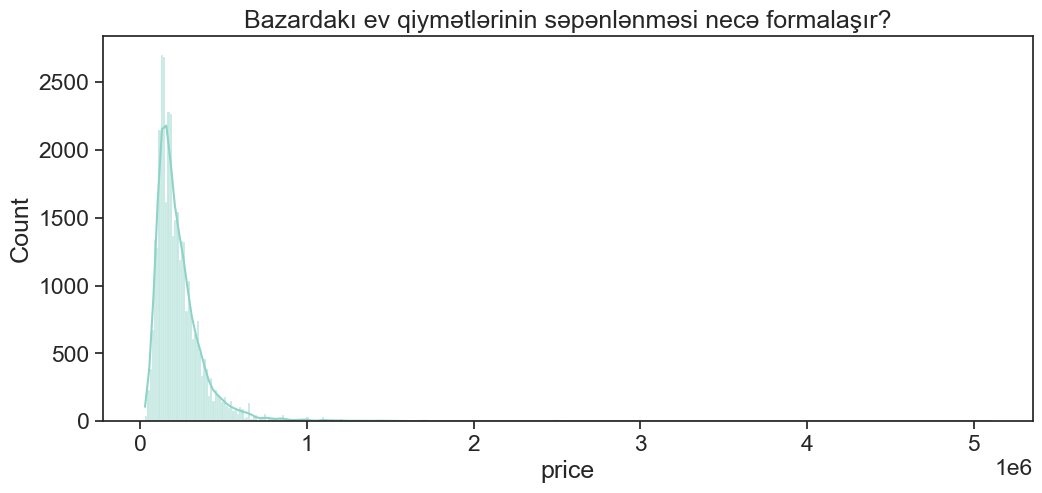

In [48]:
plt.figure(figsize=(12, 5))
main = sns.histplot(data=df, x="price", stat="count", kde=True, log_scale=False)
main.set_title(label="Bazardakı ev qiymətlərinin səpənlənməsi necə formalaşır?");

Bu formada baxanda açıq aşkar görünür ki **çox kəskin çəkildə right (positive) skewed data paylanması ilə qarşı-qarşıyayıq**. Əlbətdəki buna səbəb ümumi data çox kəskin fərqlənən dəyərlərdir. Bunu həll etməyin 2 yolu var:
1. Scaling istifadə etmək. (Əsasən qrafik üzərində log scaling istifadə edə bilərik)
2. Outlierları seçərək təmizləmək. (Əsasən İQR metoduyla çünki datamız kəskin olaraq skew göstərir və bizə skeü resistant bir metod lazımdı- İQR)

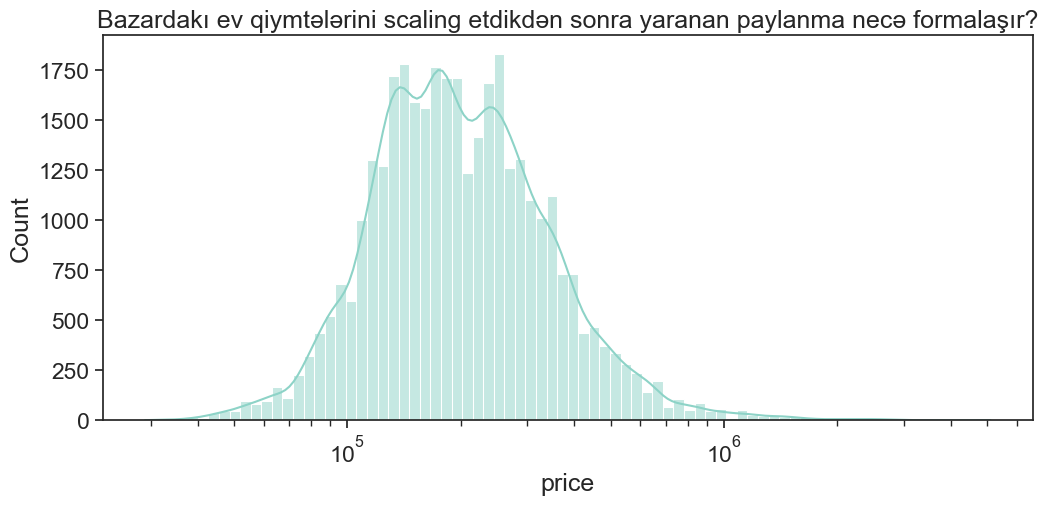

In [49]:
# Method 1:
plt.figure(figsize=(12, 5))
main = sns.histplot(data=df, x="price", stat="count", bins=80, kde=True, log_scale=True)
main.set_title("Bazardakı ev qiymtələrini scaling etdikdən sonra yaranan paylanma necə formalaşır?");

Gördüyümüz kimi Log Scaling istifadə etdik və datamız normal hala düşdü nisbətən.

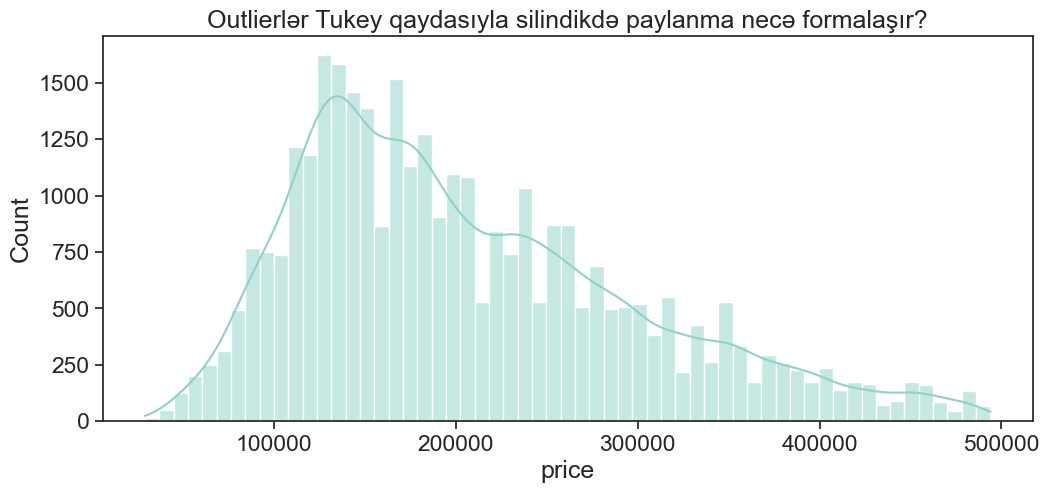

In [50]:
# Method 2: Static Graphic
Q1_Price = df["price"].quantile(q=0.25)
Q3_Price = df["price"].quantile(q=0.75)
IQR_Price = Q3_Price - Q1_Price

lower_bound = Q1_Price - 1.5*IQR_Price
upper_bound = Q3_Price + 1.5*IQR_Price

mask = (df["price"] < lower_bound) | (df["price"] > upper_bound)
plt.figure(figsize=(12, 5))
main = sns.histplot(data=df[~mask], x="price", stat="count", kde=True)
main.set_title(label="Outlierlər Tukey qaydasıyla silindikdə paylanma necə formalaşır?");

In [51]:
# Method 2:
def outlier_detector(k: float=1.5):
    Q1_Price = df["price"].quantile(q=0.25)
    Q3_Price = df["price"].quantile(q=0.75)
    IQR_Price = Q3_Price - Q1_Price

    lower_bound = Q1_Price - k*IQR_Price
    upper_bound = Q3_Price + k*IQR_Price

    mask_outlier_iqr = (df["price"] < lower_bound) | (df["price"] > upper_bound)
    plt.figure(figsize=(12, 5))
    main = sns.histplot(data=df[~mask_outlier_iqr], x="price", stat="count", kde=True)
    main.set_title(label="Outlier Multiplier seçməklə formalaşan paylanmaya siz qərar verin?");

In [52]:
widgets.interact(outlier_detector, k=(0, 5.5, 0.5));

interactive(children=(FloatSlider(value=1.5, description='k', max=5.5, step=0.5), Output()), _dom_classes=('wi…

Mən burda interaktiv olaraq graphic yaratmışam hansındakı siz outlier multiplier seçirsiz və nəticədə outlier o seçilən band genişliyindəki məlumat paylanmasını görürsüznüz. Verdiyniz dəyər daxildə outlier detection adlanan funksiya vasitəsiylə müəyyən olunur və məlumat outlierlərdən siz verdiyiniz aralıqda təmizlənir sonra vizual yaradılır. Əgər 0 a endirsəniz outlieri sadəcə Q1 və Q3 aralığındakı dəyərləri müşahidə edəcəksiziniz. 

Şərti olaraq 1.5 dəyəri bizə Tukey sərhədləri verəcək 2 isə extrimal hallar üçün nəzərdə tutulmuş sərhədi verəcək. 

### 2. Kateqoriyalara Görə Kənar Dəyərlər (Boxplot)
* Köhnə və Yeni tikililərin (**category**) qiymət paylanmasını vizuallaşdırmaq üçün qutu qrafiki (`boxplot`) yaradın.
* Qrafik üzərində anomaliyaları (kənar dəyərləri) nümayiş etdirin.

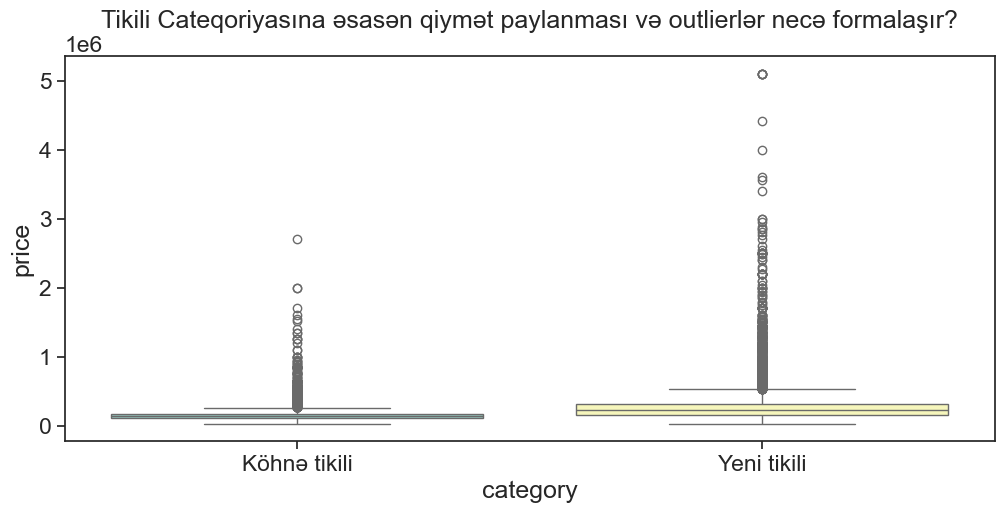

In [209]:
plt.figure(figsize=(12, 5))
main = sns.boxplot(data=df, x="category", y="price", hue="category")
main.set_title(label="Tikili Cateqoriyasına əsasən qiymət paylanması və outlierlər necə formalaşır?");

Bu qrafikimizdə demək olar ki heç nə görə bilmirik. Outlierlər o qədər kəskindir ki real dəyərləri müşahidə etmək çox çətindi.

Yenə metodlara baş vurmalıyıq: Scaling və Outlier detection and cleaning

Əlavə olaraq da biz bunu başqa bir Statistik Paylanma qrafikində baxa bilərik: Strip plot

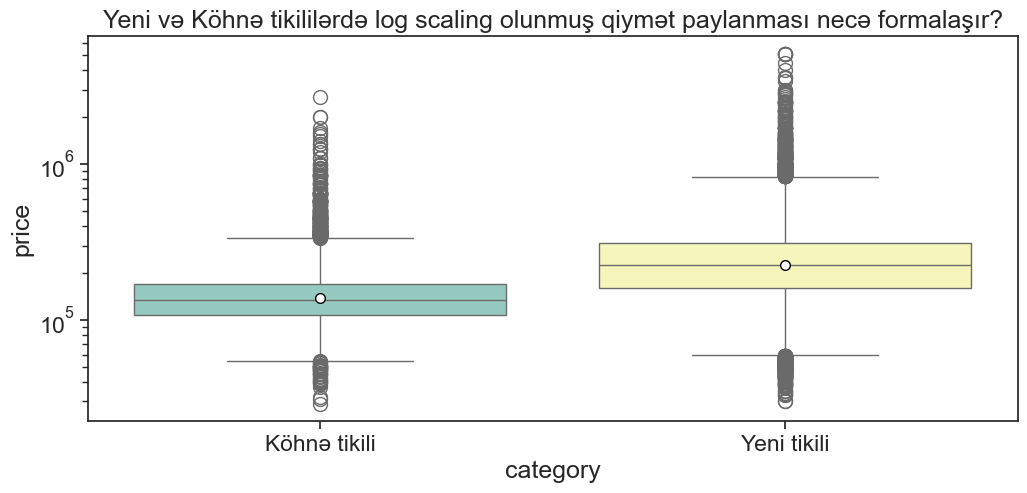

In [54]:
# Metod 1:
plt.figure(figsize=(12, 5))
main = sns.boxplot(data=df, x="category", y="price", hue="category", log_scale=True, showmeans=True, fliersize=10,
            meanprops=dict(marker="o", markersize=7, markerfacecolor="white", markeredgecolor="black"))
main.set_title(label="Yeni və Köhnə tikililərdə log scaling olunmuş qiymət paylanması necə formalaşır?");

1-ci metod olan Log Scaling metodu bizə daha aydın görüntü verir.

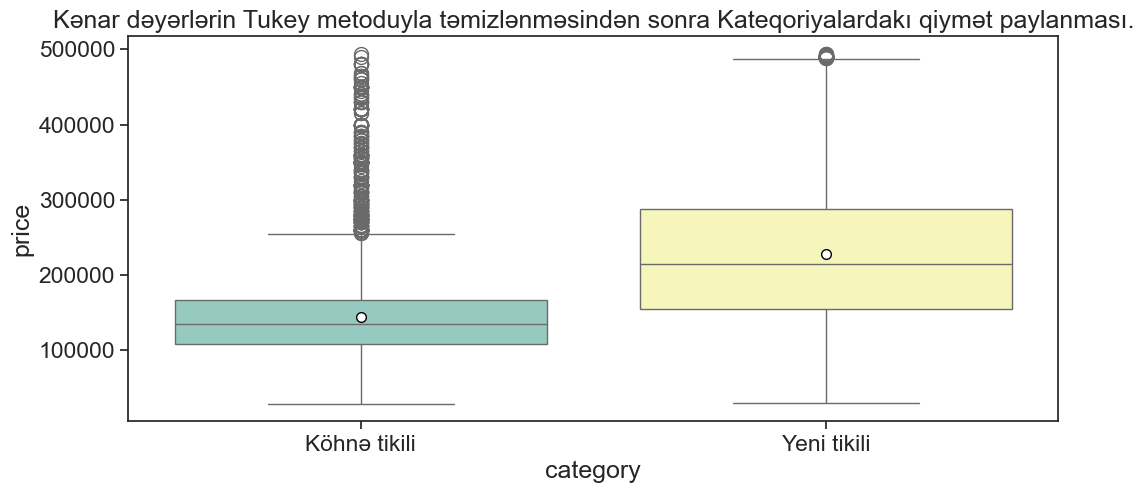

In [56]:
# Metod 2:
plt.figure(figsize=(12, 5))
main = sns.boxplot(data=df[~mask], x="category", y="price", hue="category", showmeans=True, fliersize=10,
            meanprops=dict(marker="o", markersize=7, markerfacecolor="white", markeredgecolor="black"))
main.set_title(label="Kənar dəyərlərin Tukey metoduyla təmizlənməsindən sonra Kateqoriyalardakı qiymət paylanması.");

2-ci metod olan outlier cleaning bizə aydın görüntü verir.

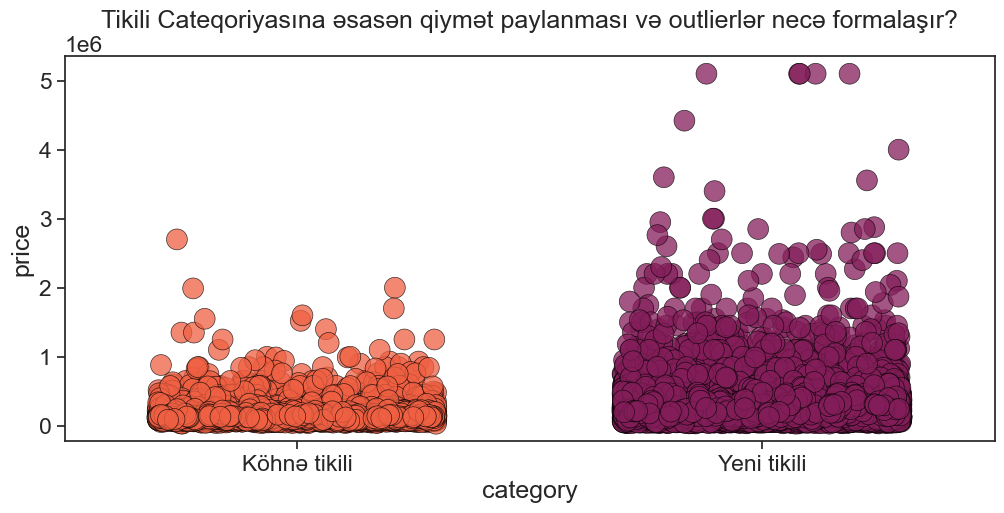

In [208]:
# Strip plot method
plt.figure(figsize=(12, 5))
main = sns.stripplot(data=df, x="category", y="price", hue="category", palette="rocket_r", alpha=0.75, 
                     size=15, edgecolor="black", linewidth=0.5, jitter=0.3)
main.set_title(label="Tikili Cateqoriyasına əsasən qiymət paylanması və outlierlər necə formalaşır?");

### 3. İkiölçülü Səpələnmə (Scatterplot)
* Mənzilin sahəsi (**area**) ilə ümumi qiyməti (**price**) arasındakı əlaqəni nümayiş etdirən səpələnmə qrafiki qurun.

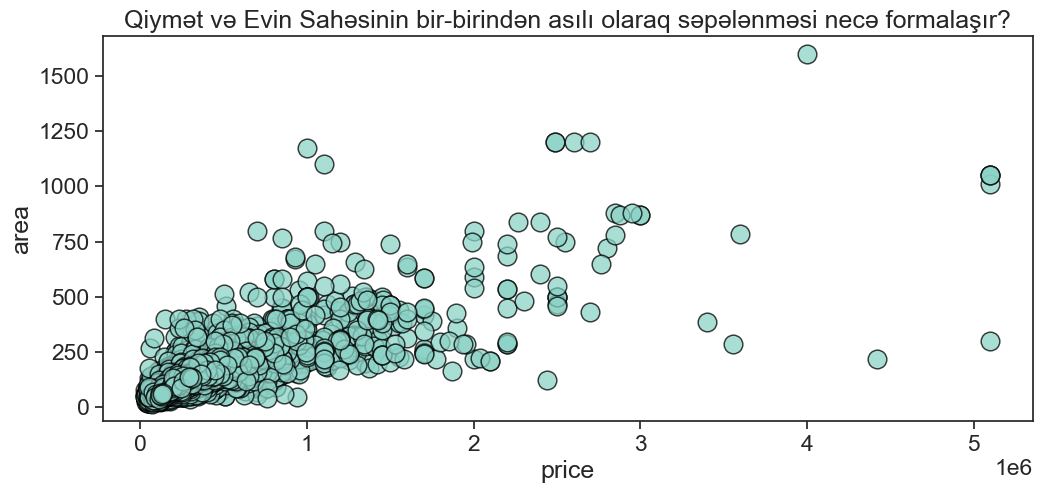

In [65]:
plt.figure(figsize=(12, 5))
main = sns.scatterplot(data=df, x="price", y="area", s=180, ec="black", alpha=0.75)
main.set_title(label="Qiymət və Evin Sahəsinin bir-birindən asılı olaraq səpələnməsi necə formalaşır?");

Burdan çıxan nəticə bizə açıq aşkar göstərir ki evlərin böyük əksəriyyəti sahə olaraq 600 qiymət olaraq 200 000 sərhədinə qədər toplanıb və ümumi olaraq müsbət düz asılıq içindədirlər. Lakin həm sahə həm də qiymət nöqteyi-nəzərindən outlierlərin olması məlumatın dağılmasında öz əksini tapır. 

### 4. Seqmentasiya Olunmuş Səpələnmə (Scatterplot with Hue)
* Yuxarıdakı tapşırıqdakı sahə və qiymət qrafikinə (`scatterplot`) **title_deed** (Çıxarış var/yox) sütununu rəng (`hue`) parametri kimi əlavə edərək vizuallaşdırın.

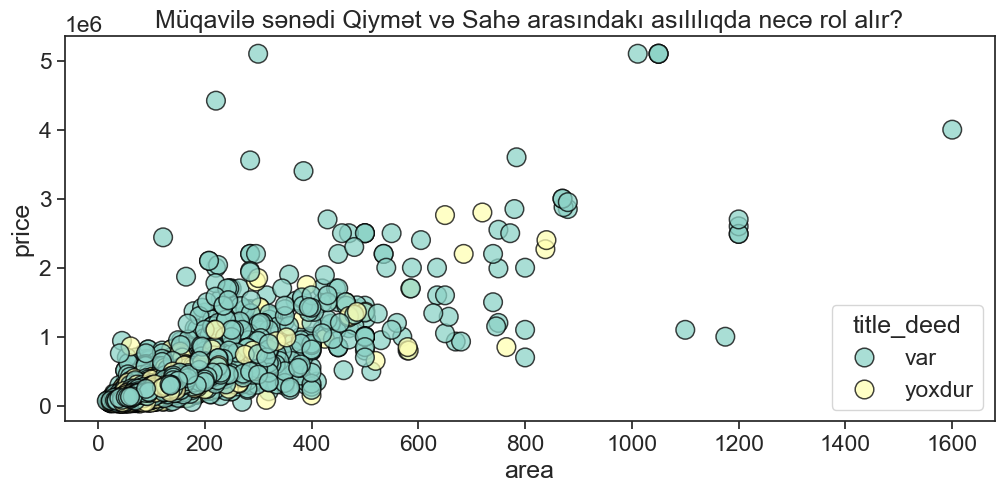

In [66]:
plt.figure(figsize=(12, 5))
main = sns.scatterplot(data=df, x="area", y="price", hue="title_deed", s=180, ec="black", alpha=0.75)
main.set_title(label="Müqavilə sənədi Qiymət və Sahə arasındakı asılılıqda necə rol alır?");

Burada da biz 2 mühüm məlumatı izləyə bilirik. Mülkiyyət sənədinin olmaması az görülən haldır amma əsasən normal qiymətlər daxilin görülür. Outlier və çox yüksək qiymət və sahəyə malik evlərdə əsasən mülkiyyət sənədi qaydasında olur.

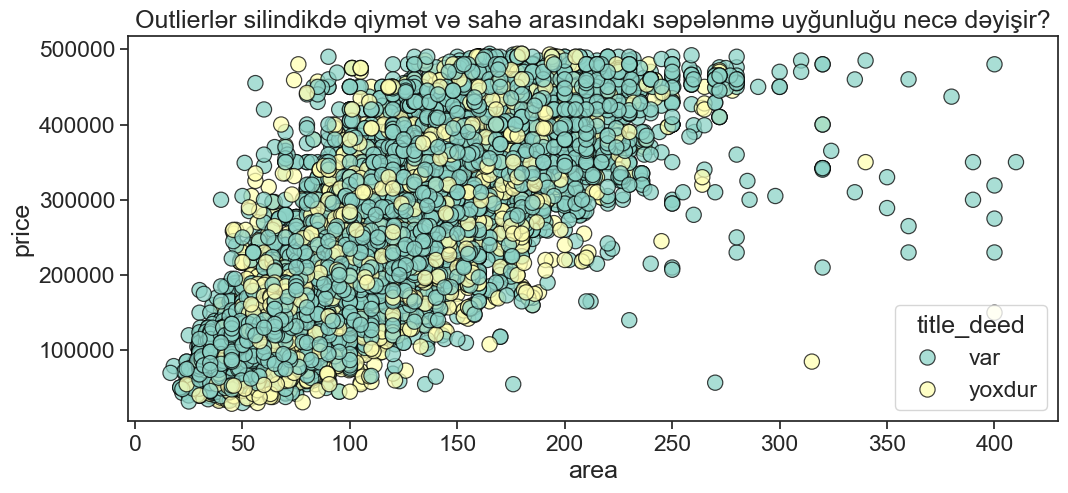

In [69]:
plt.figure(figsize=(12, 5))
main = sns.scatterplot(data=df[~mask], x="area", y="price", hue="title_deed", s=120, ec="black", alpha=0.75)
main.set_title(label="Outlierlər silindikdə qiymət və sahə arasındakı səpələnmə uyğunluğu necə dəyişir?");

Buradan görə bilərik ki sahə və qiymət arasındakı uyğunluq outlierlər silindikdə düzgün asılılıq halındadır.

Mən indi bu asılılıqda aradakı düz asılıqdakı slope -un nə qədər olduğunu müəyyən etmək üçün interactive qrafik yaradacağam.

In [116]:
def slope_and_outlier_detector(k: float=1.5, m: float=1, line: bool=False):
    plt.figure(figsize=(12, 5))
    Q1_Price = df["price"].quantile(q=0.25)
    Q3_Price = df["price"].quantile(q=0.75)
    IQR_Price = Q3_Price - Q1_Price

    lower_bound = Q1_Price - k*IQR_Price
    upper_bound = Q3_Price + k*IQR_Price
    mask_outlier_iqr = (df["price"] < lower_bound) | (df["price"] > upper_bound)

    main = sns.scatterplot(data=df[~mask_outlier_iqr], x="area", y="price", hue="title_deed", s=180, ec="black", alpha=0.75)
    main.set_title(label="Sahə və qiymət arasındakı asılıqdakı kəskinlik nə dərəcədədir?")

    if line:
        x_values = np.linspace(start=0, stop=df[~mask_outlier_iqr]["area"].max(), num=1000)
        y_values = np.linspace(start=0, stop=df[~mask_outlier_iqr]["price"].max(), num=1000)
        sns.lineplot(x=x_values, y=m*y_values, lw=3, c="#781753")
        plt.ylim(-10, df[~mask_outlier_iqr]["price"].max()+1000)
        plt.xlim(-10, df[~mask_outlier_iqr]["area"].max()+50);

In [ ]:
widgets.interact(
    slope_and_outlier_detector, 
    k=widgets.FloatSlider(description="Outlier Multiplier", min=0.0, max=5.0, step=0.5, value=1.5), 
    m=widgets.Dropdown(description="Line Slope", options=[1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5], value=1), 
    line=widgets.Checkbox(description="Enable Line", value=False)
);

interactive(children=(FloatSlider(value=1.5, description='Outlier Multiplier', max=5.0, step=0.5), Dropdown(de…

### 5. Korrelasiya Matrisi (Heatmap)
* Dataset-də olan bütün ədədi sütunlar (**price**, **area**, **room_number** və s.) arasındakı korrelasiyanı Seaborn-un `heatmap` funksiyası ilə qurun.
* Qrafikə rəqəm annotasiyalarını (`annot=True`) əlavə edin.

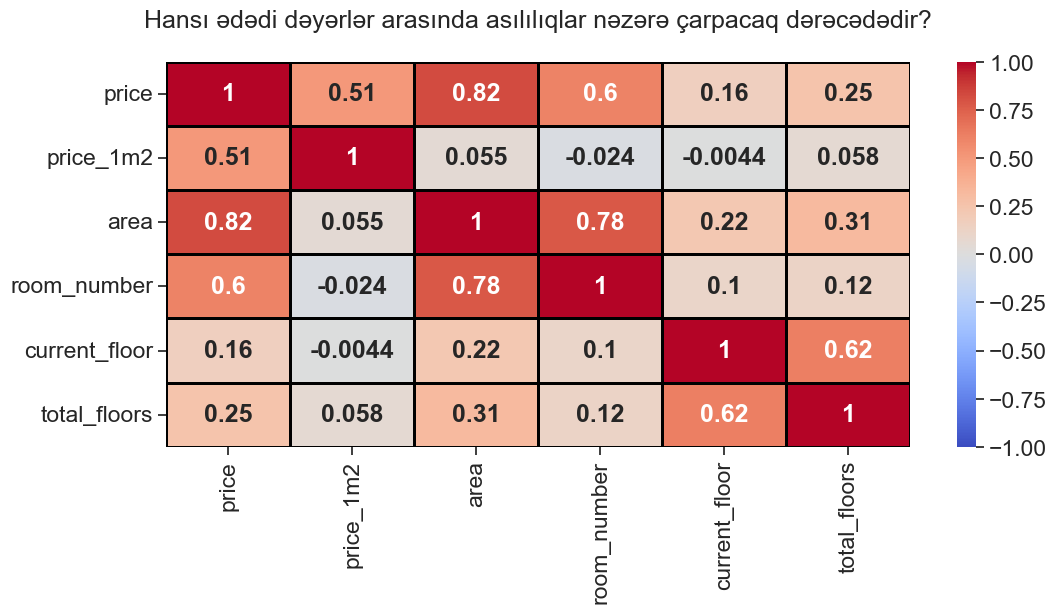

In [162]:
df_corr = df.corr(method="pearson", numeric_only=True)
plt.figure(figsize=(12, 5))
main = sns.heatmap(data=df_corr, annot=True, annot_kws=dict(weight="bold"), linewidths=1, linecolor="black",
            vmin=-1, vmax=1, center=0, cmap="coolwarm")
main.set_title(label="Hansı ədədi dəyərlər arasında asılılıqlar nəzərə çarpacaq dərəcədədir?", pad=25);

Bu heatmap qrafikinə salanda bir neçə məqam nəzərə çarpır:
1. Ciddi formada mənfi istiqamətdə meyl edən asılılıq yoxdur.
2. Əsasən dəyərlər 0 ətrafında asılıdır yəni bir o qədər də asılı deyillər.
3. Əsas 3 göstərici diqqətə çarpacaq dərəcədə asılıdır: price, area və room_number. Bunlar da causation nəticəsində bu formaya gəlib.
4. Ümumi mərtəbə sayı və sahə arasındakı çox güclü olmasa da müsbət istiqamətdəki uyğunluq buna görə formalaşır ki yeni tikililər də həm mərtəbə sayı çoxalıb həm də evlərin sahəsi çoxaldığı üçün və bizim məlumat dəstimizi əsasən yeni tikililər əhatə etdiyi üçün belə nəticə meydana çıxmış olur.

### 6. Qruplararası Müqayisə (Barplot)
* Təmirin olub-olmamasının (**repair**) mənzilin 1 kvadrat metrinin qiymətinə (**price_1m2**) təsirini `barplot` vasitəsilə göstərin.
* Qrafikdəki standart xəta xətlərini (error bars) şərh edin.

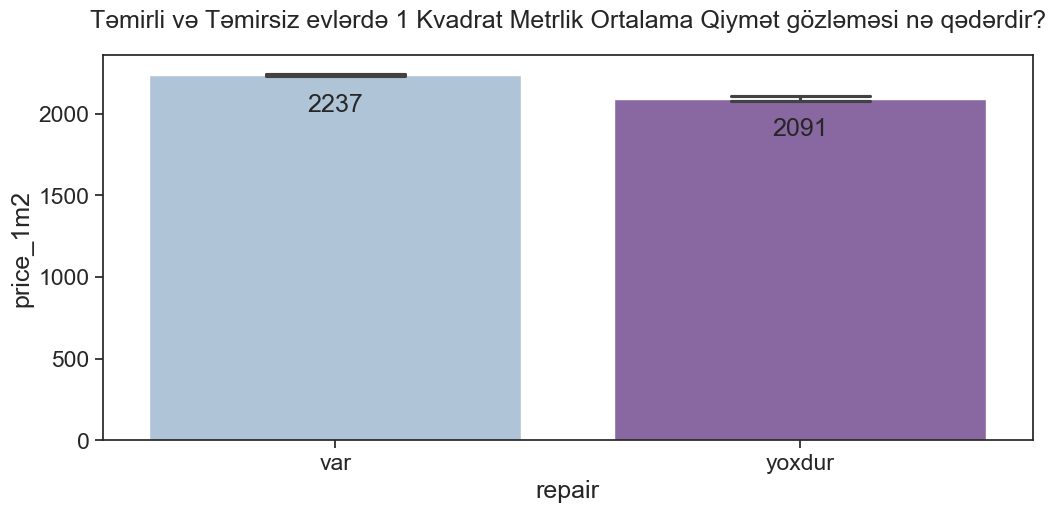

In [289]:
plt.figure(figsize=(12, 5))
main = sns.barplot(data=df, x="repair", y="price_1m2", hue="repair", estimator="mean", errorbar=("ci", 95), capsize=0.3, palette="BuPu")
main.set_title(label="Təmirli və Təmirsiz evlərdə 1 Kvadrat Metrlik Ortalama Qiymət gözləməsi nə qədərdir?", pad=20)
main.bar_label(main.containers[0], fmt='%.0f', padding=-30)
main.bar_label(main.containers[1], fmt='%.0f', padding=-30);

Burada ümumi olaraq mean qiymətlərə əsasən təmirli və təmirsiz evlərin kvadrat metr qiymətləri müqayisə olunur. Nəzərə çarpacaq məlumat təmirlilərin qiymətini bir qədər yüksək olması və həmçinin error barın daha nazik yerləşməsidi. Bu isə deməyə əsas verir ki repair olan evlərdə təxmini qiymət elə göstərilən miqdardadır. Təmiri olmayan evlərdə isə qiymət nisbətən biraz aşağı və error bar da biraz daha genişdir. Yəni dəyişkənlik ola bilər amma ümumən aşağıdır.

Ümumilikdə isə kvadrat metr qiymətlərinin ümumi qiymətlər qədər kəskin olmamasına səbəb yəqin ki sahələrin bəzi evlərdə və ya daşınmaz əmlaklarda çox daha geniş olmasıyla səciyyələnir.

### 7. Sıxlıq Paylanması (KDEplot)
* Müxtəlif **category** növlərinin (Köhnə və Yeni tikili) sahə (**area**) üzrə paylanmasını eyni qrafik üzərində göstərin.
* Bunun üçün çoxqatlı (`multiple`) `kdeplot` yaradın.

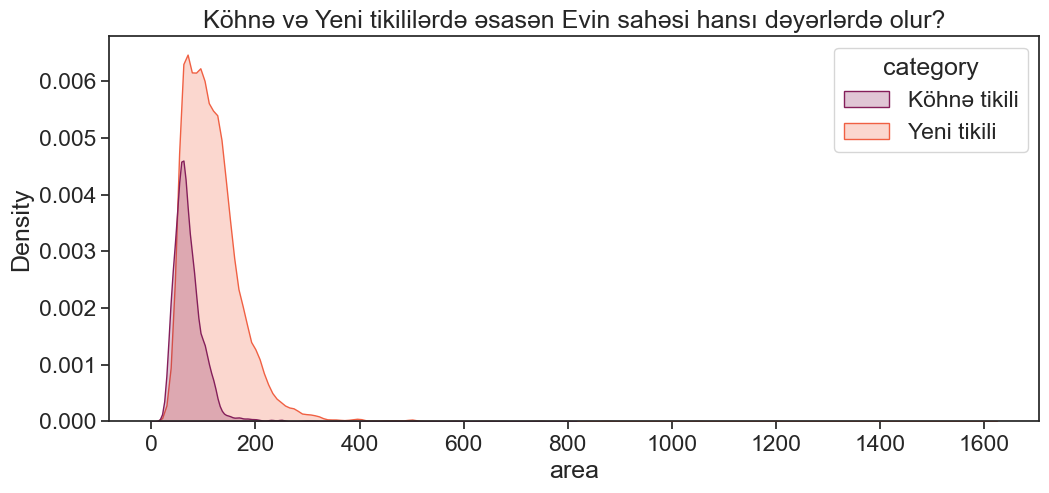

In [192]:
plt.figure(figsize=(12, 5))
main = sns.kdeplot(data=df, x="area", hue="category", palette="rocket", multiple="layer", fill=True)
main.set_title(label="Köhnə və Yeni tikililərdə əsasən Evin sahəsi hansı dəyərlərdə olur?");

Buradan görə bilərik ki bəzi evlərin sahələri kəskin outlier olduğu üçün paylanma sıxlığı bu formada reallaşır. Amma diqqətlə analiz etsək görərik ki əsasən köhnə tikililərdə 200-ə yeni tikililərdə isə 400-ə qədər evlər var. Amma ən böyük sıxlıq hər iki kateqoriya üçün 100-ətrafındadır.

Bunu daha aydın izləmək ünün scaling və outlier detection istifadə edərək baxaq:

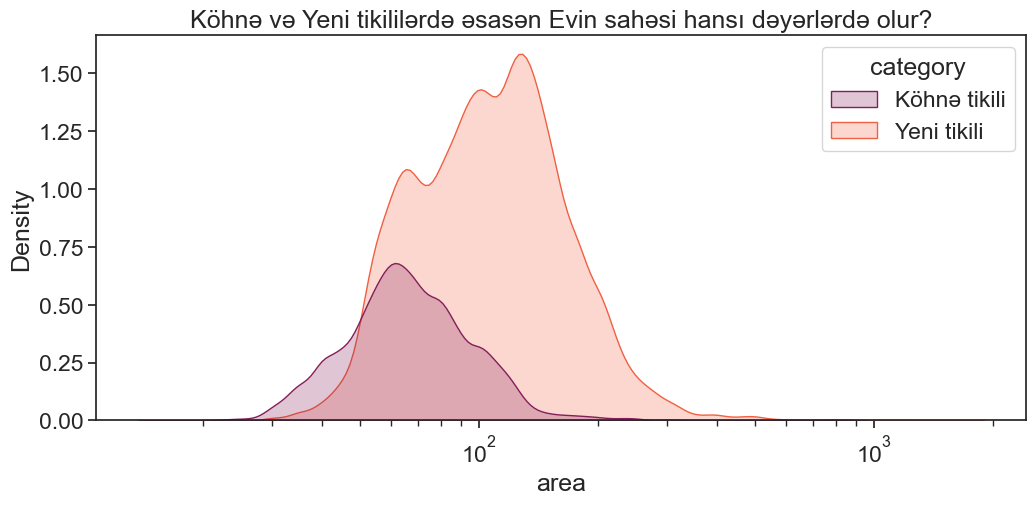

In [195]:
# Metod 1: Log scalingdən sonra
plt.figure(figsize=(12, 5))
main = sns.kdeplot(data=df, x="area", hue="category", palette="rocket", multiple="layer", fill=True, log_scale=True)
main.set_title(label="Köhnə və Yeni tikililərdə əsasən Evin sahəsi hansı dəyərlərdə olur?");

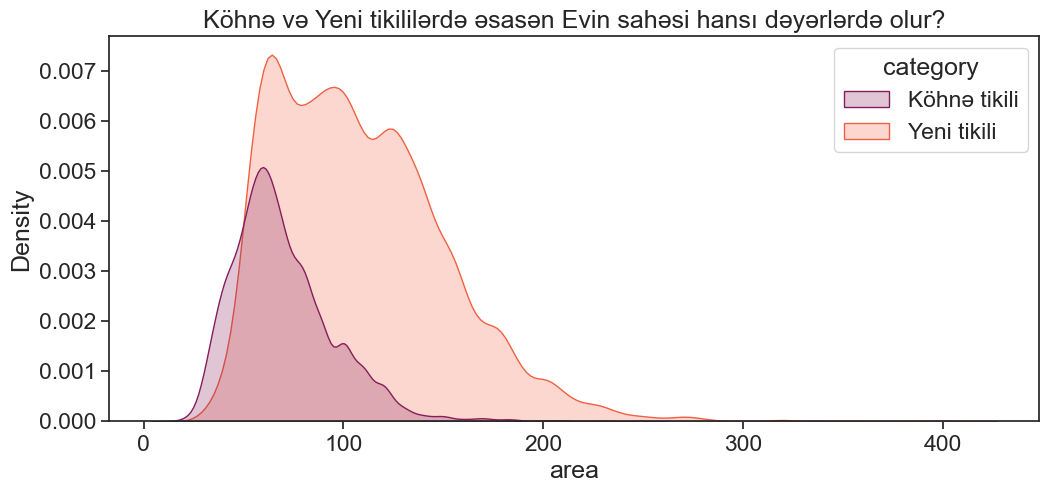

In [196]:
# Metod 2: Outlier Cleaning-dən sonra
plt.figure(figsize=(12, 5))
main = sns.kdeplot(data=df[~mask], x="area", hue="category", palette="rocket", multiple="layer", fill=True)
main.set_title(label="Köhnə və Yeni tikililərdə əsasən Evin sahəsi hansı dəyərlərdə olur?");

### 8. Çoxölçülü Müqayisə (Pairplot)
* **room_number**, **area**, **price_1m2** və **price** sütunlarından ibarət `pairplot` qurun.
* Dəyişənlərin ikili kombinasiyalarını və fərdi paylanmalarını vizuallaşdırın.

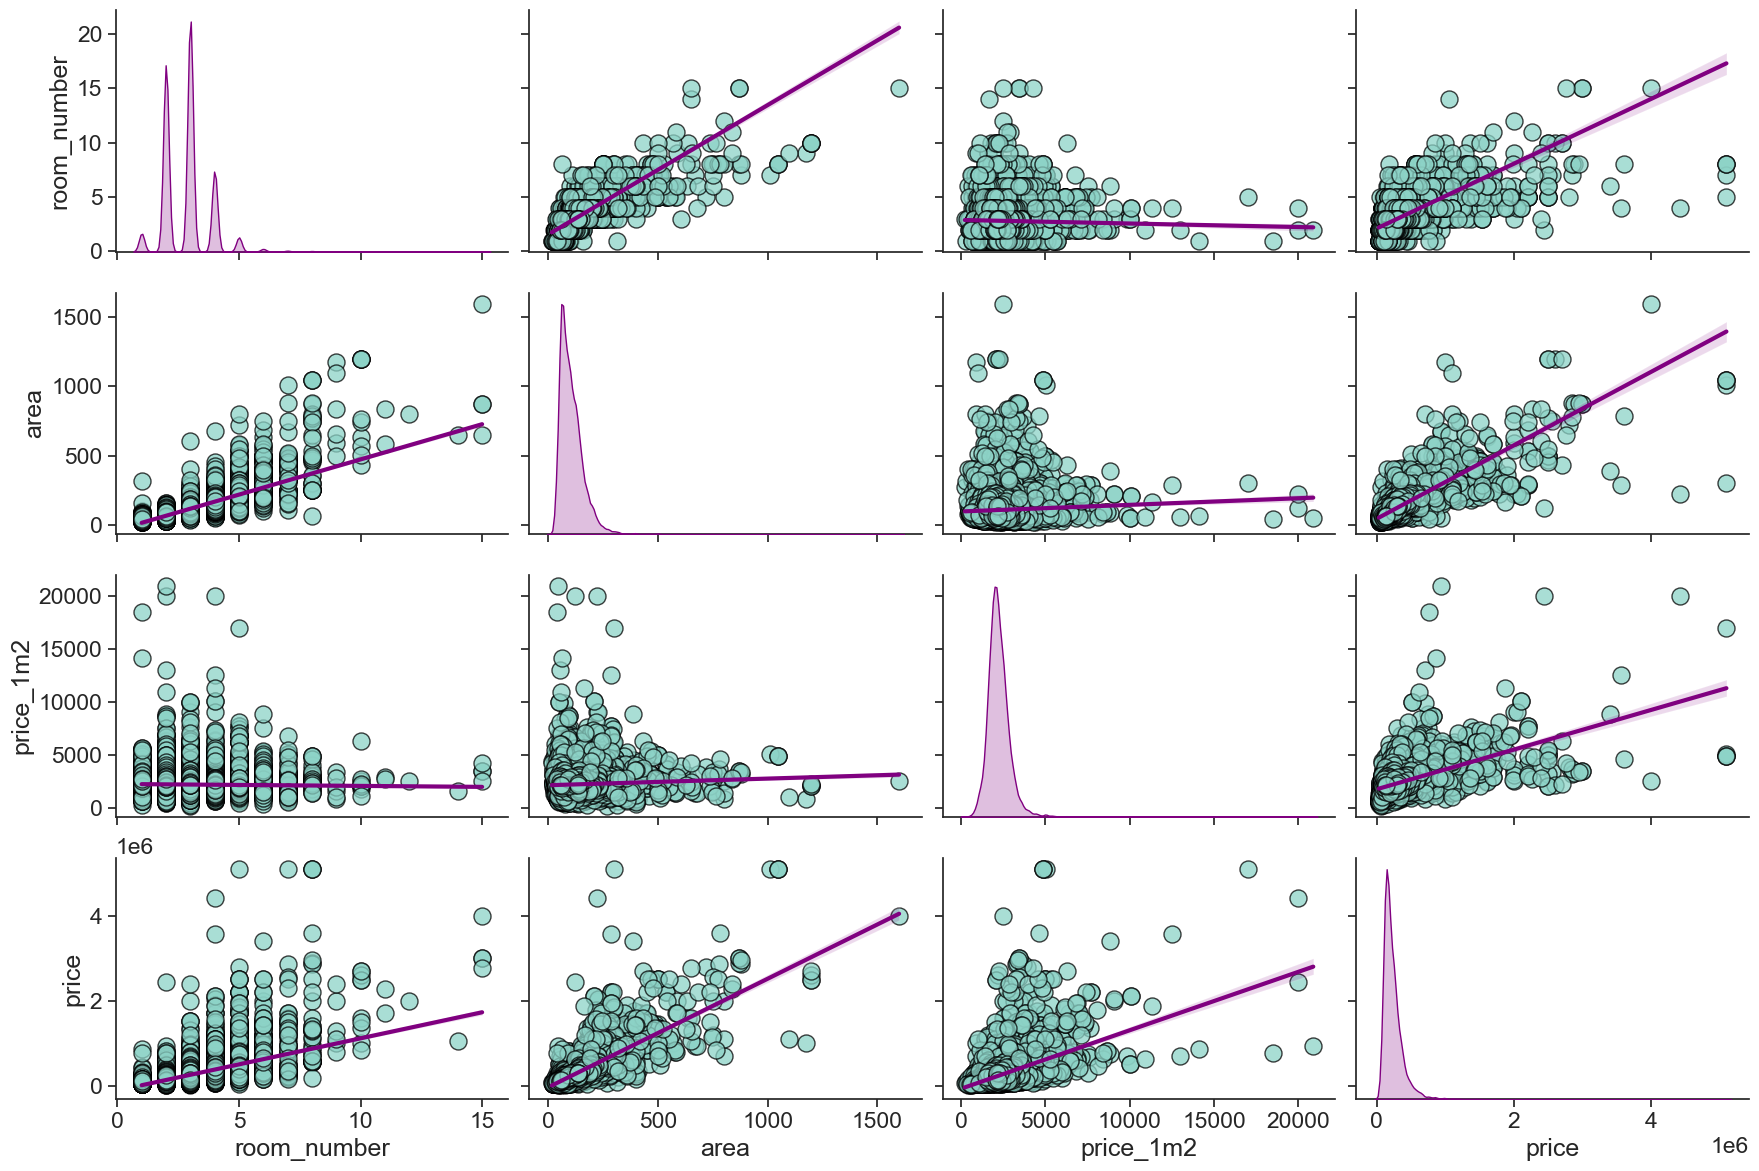

In [239]:
sns.pairplot(data=df, vars=["room_number", "area", "price_1m2", "price"], height=3, aspect=1.5,
             diag_kind="kde", kind="reg",
             plot_kws=dict(scatter_kws=dict(s=150, ec="black", alpha=0.75), line_kws=dict(lw=3, color="purple")),
             diag_kws=dict(color="purple"));

Analitik nəticəyə gələsi olsaq, bir neçə mühüm məsələ ilə üz üzəyik:
1. Ilk öncə diqqətinzə çatdırmaq istəyirəm ki bu qrafikdə diaqonal olanlar univariate yəni birdəyişən KDEplot olaraq nəzərdə tutulur və uyğun X oxlarının dəyərlərinin paylanmasını göstərir.
2. Digər graphiclər isə scatter plot olaraq 2 ədədi dəyişənin arasındakı asılılığı göstərir.
3. Otaq sayı əsasən 2, 3, 4 otaqlı evlərdən təşkil olunub, Sahə 500-ə, kvadratmetr qiyməti 5000-ə qədər, ümumi qiymət isə əsasən 500 000 -ə qədər nəzərə çarpır. 
4. Otaq sayı sahə və qiymətdən düz asılı, kvadrat metr qiymətindən isə demək olar ki asılı deyil.
5. Sahə eyni qaydada, ümumi qiymət və otaq sayı ilə düz asılı positive istiqamətdə amma kvadratmetr ilə bir o qədər də asılı deyil.
6. Ümumi qiymət digər bütün dəyişənlərdən açıq aşkar düz asılılıqdadı.
7. Kvadrat metr qiyməti isə qiymət və sahəylə düz asılı olsa da demək olar ki otaq sayı nə qədər dəyişsə də sabit qalır yəni asılı deyil.

### 9. Violin Qrafiki (Violinplot)
* Sonradan yaradılan "binanın ümumi mərtəbə sayı" (**total_floors**) dəyişəninin **category** (Köhnə/Yeni tikili) üzrə paylanma sıxlığını və daxili strukturunu görmək üçün `violinplot` qurun.

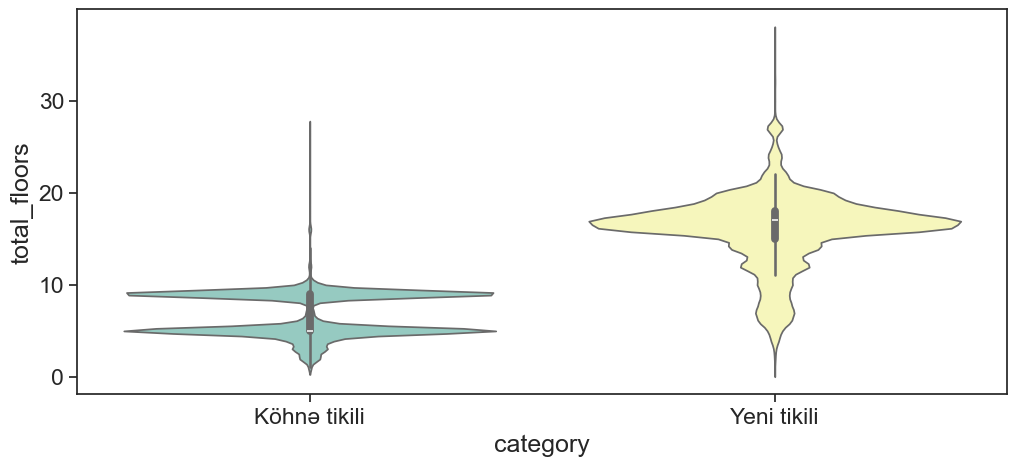

In [264]:
plt.figure(figsize=(12, 5))
sns.violinplot(data=df, x="category", y="total_floors", hue="category", density_norm="area");

Son olaraq bu analizin nəticələrini müzakirə edəsi olsaq, yenə bəzi mühim məqamları diqqət çəkir:
1. Açıq aşkar görünür ki köhnə tikililər də əsasən bina sayı 5-ə qədər və 10 civarındadır.
2. Yeni tikililərdə isə bu göstərici əsasən 20 civarında paylanıb.
3. Son olaraq daxildəki kiçik box plota nəzər salsaq görərik ki median olaraq Köhnə Binalarda 5, Yeni Binalarda isə təxminən 17-18 diqqətə çarpır.

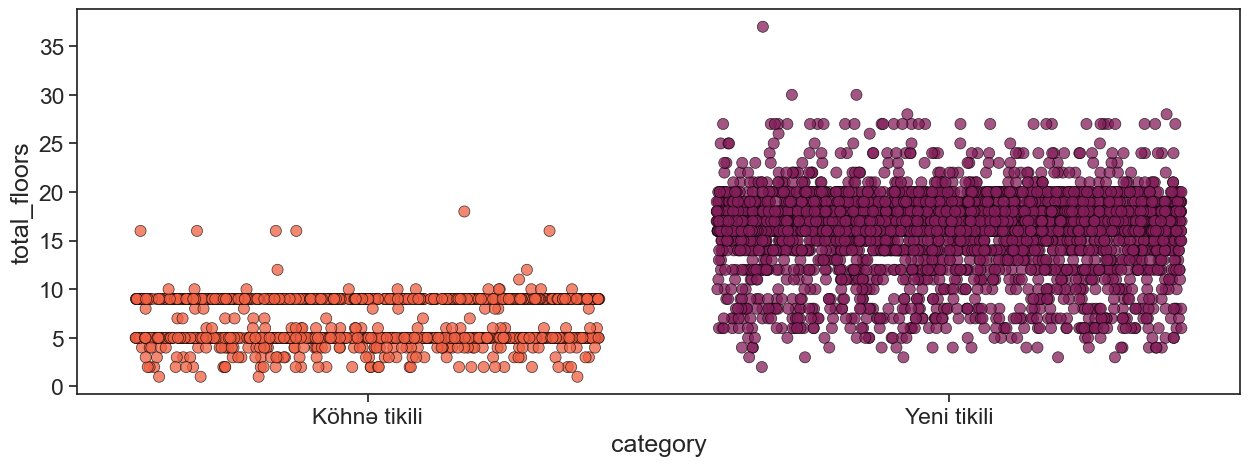

In [286]:
plt.figure(figsize=(15, 5))
sns.stripplot(data=df.sample(n=5_000), x="category", y="total_floors", hue="category", palette="rocket_r", jitter=0.4,
              size=8, edgecolor="black", linewidth=0.5, alpha=0.75);

Daha aydın analizin nəticəsi belə məlum olur. Biz stripplot istifadə edirik amma bunun üçün sample olaraq təsadüfü seçilmiş təxminən 10% lik datadan istifdə edirik və nəticədə açıq aşkar bir neçə şey məlum olur:
1. Yeni tikililərin bazarda tutduğu Köhnə tikililərlə müqayisədə çox daha böyükdür.
2. Yeni tikililərdə əsas bina mərtəbəsi 20 ətrafında köhnə tikililərdə isə 5 və 10 ətrafında paylanmışdır.